In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

In [2]:
import os 
from sklearn.model_selection import train_test_split 
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model 
from keras.layers import GlobalAveragePooling2D, Dense, Flatten, Dropout,BatchNormalization
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger

In [3]:
data = []
labels = []
classes = 43 
cur_path = os.getcwd() 
for i in range(classes): 
    path = os. path.join(cur_path,'train', str(i)) 
    images = os.listdir(path) 
    for a in images: 
        try: 
            image = Image.open(path + '/' + a) 
            image = image.resize((50,50)) 
            image = np.array(image) 
            data.append(image) 
            labels.append(i) 
        except: 
            print("Error loading image") 
data = np.array(data)
labels = np.array(labels)

In [4]:
print(data.shape, labels.shape)

(39209, 50, 50, 3) (39209,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=11)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(31367, 50, 50, 3) (7842, 50, 50, 3) (31367,) (7842,)


In [7]:
resnet = ResNet50(weights= None, include_top=False, input_shape= (50,50,3))

In [9]:
x = resnet.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(43, activation= 'softmax')(x)
model = Model(inputs = resnet.input, outputs = predictions)

In [13]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 50, 50, 3)]  0           []                               
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 56, 56, 3)    0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 25, 25, 64)   9472        ['conv1_pad[0][0]']              
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 25, 25, 64)   256         ['conv1_conv[0][0]']             
                                                                                              

                                                                                                  
 conv2_block3_2_bn (BatchNormal  (None, 13, 13, 64)  256         ['conv2_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block3_2_relu (Activatio  (None, 13, 13, 64)  0           ['conv2_block3_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block3_3_conv (Conv2D)   (None, 13, 13, 256)  16640       ['conv2_block3_2_relu[0][0]']    
                                                                                                  
 conv2_block3_3_bn (BatchNormal  (None, 13, 13, 256)  1024       ['conv2_block3_3_conv[0][0]']    
 ization) 

                                                                                                  
 conv3_block3_2_bn (BatchNormal  (None, 7, 7, 128)   512         ['conv3_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block3_2_relu (Activatio  (None, 7, 7, 128)   0           ['conv3_block3_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block3_3_conv (Conv2D)   (None, 7, 7, 512)    66048       ['conv3_block3_2_relu[0][0]']    
                                                                                                  
 conv3_block3_3_bn (BatchNormal  (None, 7, 7, 512)   2048        ['conv3_block3_3_conv[0][0]']    
 ization) 

                                                                                                  
 conv4_block2_2_bn (BatchNormal  (None, 4, 4, 256)   1024        ['conv4_block2_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block2_2_relu (Activatio  (None, 4, 4, 256)   0           ['conv4_block2_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block2_3_conv (Conv2D)   (None, 4, 4, 1024)   263168      ['conv4_block2_2_relu[0][0]']    
                                                                                                  
 conv4_block2_3_bn (BatchNormal  (None, 4, 4, 1024)  4096        ['conv4_block2_3_conv[0][0]']    
 ization) 

 n)                                                                                               
                                                                                                  
 conv4_block5_3_conv (Conv2D)   (None, 4, 4, 1024)   263168      ['conv4_block5_2_relu[0][0]']    
                                                                                                  
 conv4_block5_3_bn (BatchNormal  (None, 4, 4, 1024)  4096        ['conv4_block5_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block5_add (Add)         (None, 4, 4, 1024)   0           ['conv4_block4_out[0][0]',       
                                                                  'conv4_block5_3_bn[0][0]']      
                                                                                                  
 conv4_blo

 n)                                                                                               
                                                                                                  
 conv5_block2_3_conv (Conv2D)   (None, 2, 2, 2048)   1050624     ['conv5_block2_2_relu[0][0]']    
                                                                                                  
 conv5_block2_3_bn (BatchNormal  (None, 2, 2, 2048)  8192        ['conv5_block2_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block2_add (Add)         (None, 2, 2, 2048)   0           ['conv5_block1_out[0][0]',       
                                                                  'conv5_block2_3_bn[0][0]']      
                                                                                                  
 conv5_blo

In [17]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [18]:
model_check = ModelCheckpoint('best_model.h5', monitor='val_accuracy', verbose=0, save_best_only=True, mode='max')
early = EarlyStopping(monitor='val_accuracy', min_delta=0, patience=5, verbose=0, mode='max', restore_best_weights=True)
csv_logger = CSVLogger('train_log.csv', separator=',')

In [20]:
n_epochs = 25
history =  model.fit(X_train, y_train,  batch_size = 32, epochs = n_epochs, verbose = 1, 
              validation_data = (X_test, y_test), callbacks = [model_check, early, csv_logger])

Epoch 1/25
981/981 [==============================] - 2431s 2s/step - loss: 3.5623 - accuracy: 0.1559 - val_loss: 2.2349 - val_accuracy: 0.3183
Epoch 2/25
981/981 [==============================] - 2246s 2s/step - loss: 1.4495 - accuracy: 0.5476 - val_loss: 0.9698 - val_accuracy: 0.6840
Epoch 3/25
981/981 [==============================] - 2305s 2s/step - loss: 0.4815 - accuracy: 0.8501 - val_loss: 0.2581 - val_accuracy: 0.9202
Epoch 4/25
981/981 [==============================] - 2285s 2s/step - loss: 0.2851 - accuracy: 0.9156 - val_loss: 0.1406 - val_accuracy: 0.9565
Epoch 5/25
981/981 [==============================] - 2276s 2s/step - loss: 0.1844 - accuracy: 0.9469 - val_loss: 0.2053 - val_accuracy: 0.9359
Epoch 6/25
981/981 [==============================] - 2265s 2s/step - loss: 0.1155 - accuracy: 0.9671 - val_loss: 0.0833 - val_accuracy: 0.9745
Epoch 7/25
981/981 [==============================] - 2282s 2s/step - loss: 0.0893 - accuracy: 0.9750 - val_loss: 0.2161 - val_accuracy:

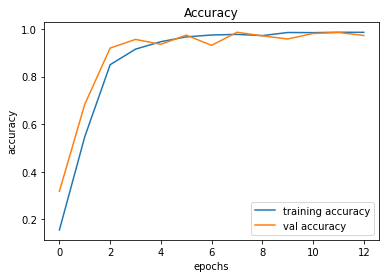

In [21]:
plt.figure(0)
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

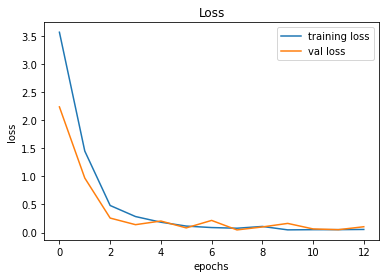

In [22]:
plt.figure(1)
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [24]:
from sklearn.metrics import accuracy_score
y_test = pd.read_csv('Test.csv')
labels = y_test["ClassId"].values
imgs = y_test["Path"].values
data=[]
for img in imgs:
   image = Image.open(img)
   image = image.resize((50,50))
   data.append(np.array(image))
X_test=np.array(data)
predict_x=model.predict(X_test) 
classes_x=np.argmax(predict_x,axis=1)

In [25]:
from sklearn.metrics import accuracy_score
print(accuracy_score(labels, classes_x))

0.939667458432304


In [26]:
model.save('traffic_classifier_resnet50.h5')